# t-SNE — Dimensionality Reduction

## Table of Contents

1. [Key Concepts](#1-key-concepts)
2. [Distance & Similarity Metrics](#2-distance--similarity-metrics)
3. [Pseudo-Algorithm](#3-pseudo-algorithm)
4. [Implementation](#4-implementation)
   - [With Scikit-learn](#with-scikit-learn)
   - [With ifri-mini-ml-lib](#with-ifri-mini-ml-lib)
5. [Benchmarking](#5-benchmarking)
6. [Real-life Applications](#6-real-life-applications)
7. [Limitations and Challenges](#7-limitations-and-challenges)
8. [References](#8-references)

---

## 1. Key Concepts

### What is dimensionality reduction?

Real-world datasets often contain dozens or hundreds of variables (dimensions). The **Digits dataset**, for example, represents each handwritten digit as an 8×8 pixel image — that is **64 dimensions** per data point. Visualizing or understanding such data directly is impossible.

**Dimensionality reduction** transforms high-dimensional data into a lower-dimensional representation (typically 2D or 3D) **while preserving the essential structure of the data**.

| Problem | How reduction helps |
|---------|--------------------|
| Cannot visualize 64D data | Project to 2D/3D |
| Slow training | Fewer features = faster computation |
| Redundant features | Compress information |
| Overfitting | Remove noise |

### What is t-SNE?

**t-SNE** (*t-Distributed Stochastic Neighbor Embedding*), introduced by Van der Maaten & Hinton (2008), is a **non-linear** dimensionality reduction algorithm specifically designed for **visualization**. Unlike PCA (which preserves global variance), t-SNE focuses on **preserving local neighborhoods**: points that are close in the original high-dimensional space should remain close in the 2D projection.

### t-SNE vs PCA

| | PCA | t-SNE |
|--|-----|-------|
| Type | Linear | Non-linear |
| Goal | Maximum variance | Neighborhood preservation |
| Use case | Compression + visualization | Visualization only |
| Speed | Fast | Slow (O(n²)) |
| Complex clusters | Limited | Excellent |
| Reproducibility | Deterministic | Stochastic (needs `random_state`) |

### Key parameters

| Parameter | Role | Recommended value |
|-----------|------|-------------------|
| `perplexity` | Effective number of neighbors considered per point | 5 – 50 (default: 30) |
| `n_components` | Target number of dimensions | 2 |
| `learning_rate` | Controls convergence speed of gradient descent | 10 – 1000 (default: 200) |
| `n_iter` | Maximum number of optimization iterations | 1000 |
| `early_exaggeration` | Amplifies P for the first 250 iterations to help clusters form faster | 12.0 |

**Perplexity** is the most important parameter. Think of it as a smooth measure of the number of effective neighbors. Low values (5–10) create many small, tight clusters. High values (40–50) tend to merge clusters. Values between **20 and 40** generally give the best results.

## 2. Distance & Similarity Metrics

t-SNE does not use distance metrics directly for classification, but it relies on **pairwise similarity scores** derived from distances. Understanding these is essential to understand how the algorithm works.

### Gaussian similarity in high-dimensional space

Given two points $x_i$ and $x_j$ in the original space, their **conditional similarity** is defined as:

$$p_{j|i} = \frac{\exp\left(-\|x_i - x_j\|^2 \;/\; 2\sigma_i^2\right)}{\displaystyle\sum_{k \neq i} \exp\left(-\|x_i - x_k\|^2 \;/\; 2\sigma_i^2\right)}$$

- $\|x_i - x_j\|^2$ is the squared **Euclidean distance** between $x_i$ and $x_j$
- $\sigma_i$ is a bandwidth parameter adapted to each point so that the effective number of neighbors matches the chosen `perplexity`
- Close points → high $p_{j|i}$. Distant points → $p_{j|i} \approx 0$

The matrix P is **symmetrized** as: $p_{ij} = \dfrac{p_{j|i} + p_{i|j}}{2n}$

### Student's t-distribution similarity in 2D

In the low-dimensional space, t-SNE uses the **Student's t-distribution** (with 1 degree of freedom) instead of a Gaussian:

$$q_{ij} = \frac{\left(1 + \|y_i - y_j\|^2\right)^{-1}}{\displaystyle\sum_{k \neq l}\left(1 + \|y_k - y_l\|^2\right)^{-1}}$$

The heavier tails of the t-distribution allow **moderately distant points in 2D to represent very distant points in the original space**, which prevents the "crowding problem" typical of methods using Gaussian distributions in both spaces.

### Why two different distributions?

In high dimensions, distances between points are nearly all equal (the *curse of dimensionality*). Using a Gaussian in high-D and a t-distribution in 2D creates an asymmetry that:
- Keeps truly close points close in 2D (clusters are tight)
- Pushes far-away points even further apart in 2D (clusters are well-separated)

This asymmetry is what makes t-SNE produce visually clean cluster structures.

## 3. Pseudo-Algorithm

t-SNE operates in two phases: computing similarities in the original space, then iteratively optimizing a 2D layout to match those similarities.

---

```
INPUT:  Data matrix X  (n samples × d dimensions)
        Perplexity, n_iter, learning_rate
OUTPUT: Low-dimensional embedding Y  (n samples × 2)

── PHASE 1: Compute high-dimensional similarities (done once) ──────────────

FOR each point i:
    Binary search for σᵢ such that the perplexity of p(·|i) equals the target
    FOR each point j ≠ i:
        Compute p(j|i) using Gaussian kernel with bandwidth σᵢ

Symmetrize: pᵢⱼ = (p(j|i) + p(i|j)) / 2n

── PHASE 2: Gradient descent optimization ──────────────────────────────────

Initialize Y randomly (small values around 0)

FOR t = 1 to n_iter:

    [Early exaggeration phase: if t < 250, multiply all pᵢⱼ by 4]

    FOR each pair (i, j):
        Compute qᵢⱼ using Student t-distribution on current Y positions

    Compute KL divergence:  KL(P ∥ Q) = Σᵢⱼ pᵢⱼ · log(pᵢⱼ / qᵢⱼ)

    Compute gradient:       ∂KL/∂yᵢ = 4 Σⱼ (pᵢⱼ - qᵢⱼ)(yᵢ - yⱼ)(1 + ‖yᵢ-yⱼ‖²)⁻¹

    Update positions:       Y ← Y - learning_rate × gradient   (+ momentum)

RETURN Y
```

---

**Key observations from the pseudo-algorithm:**

- **Phase 1 is computed only once.** The similarity matrix P is fixed throughout optimization. Only Q changes as Y is updated.
- **Binary search for σᵢ** is the mechanism that makes perplexity meaningful: each point gets its own bandwidth adapted to the local density of its neighborhood.
- **Early exaggeration** (multiplying P by 4 in the first 250 iterations) forces the algorithm to form compact clusters early, making the final layout easier to interpret.
- **The gradient** has an intuitive form: if $p_{ij} > q_{ij}$, points $i$ and $j$ are too far apart in 2D → they attract each other. If $p_{ij} < q_{ij}$, they are too close → they repel each other.
- **Complexity is O(n²)** per iteration because all pairwise similarities must be computed.

## 4. Implementation

We demonstrate t-SNE on the **Digits dataset**: 1797 images of handwritten digits (0–9), each represented as a vector of 64 pixel values. We use a **subset of 500 samples** to keep computation tractable with our pure-NumPy implementation.

> **Note on the dataset:** Since our implementation has O(n²) complexity, we work on a subset. Scikit-learn's Barnes-Hut approximation (O(n log n)) can handle the full dataset.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE as SklearnTSNE
import sys
sys.path.append("../../../")
from ifri_mini_ml_lib.preprocessing.dimensionality_reduction import TSNE

# Load and normalize data
digits = load_digits()
X = digits.data
y = digits.target
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

# Select a reproducible subset of 500 samples
np.random.seed(42)
indices = np.random.choice(len(X), 500, replace=False)
X_sub, y_sub = X[indices], y[indices]

print(f"Working subset: {X_sub.shape}  ({len(np.unique(y_sub))} digit classes)")

Working subset: (500, 64)  (10 digit classes)


### With Scikit-learn

Scikit-learn — KL: 0.6143  |  Time: 2.03s


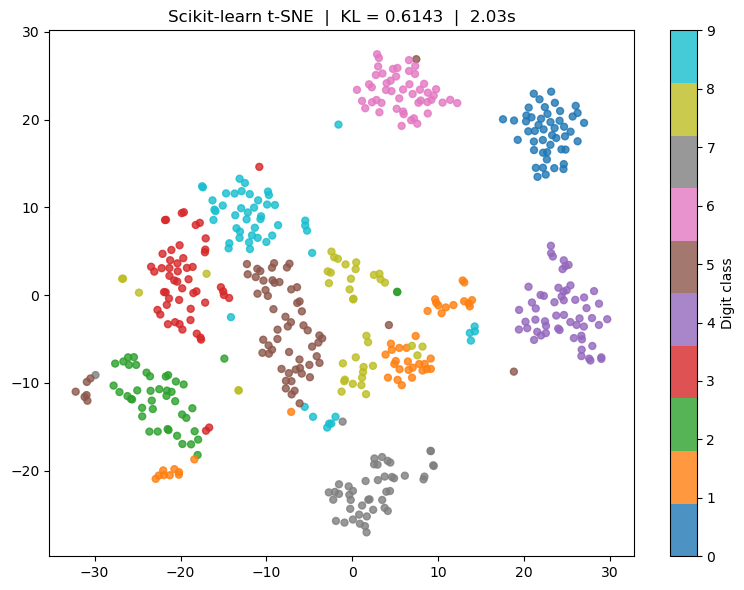

In [19]:
tsne_sk = SklearnTSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)

start = time.time()
Y_sklearn = tsne_sk.fit_transform(X_sub)
time_sklearn = time.time() - start

print(f"Scikit-learn — KL: {tsne_sk.kl_divergence_:.4f}  |  Time: {time_sklearn:.2f}s")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(Y_sklearn[:, 0], Y_sklearn[:, 1], c=y_sub, cmap='tab10', alpha=0.8, s=25)
plt.colorbar(scatter, label='Digit class')
plt.title(f'Scikit-learn t-SNE  |  KL = {tsne_sk.kl_divergence_:.4f}  |  {time_sklearn:.2f}s')
plt.tight_layout()
plt.show()

### With ifri-mini-ml-lib

ifri-mini-ml-lib — KL: 0.5597  |  Time: 51.32s


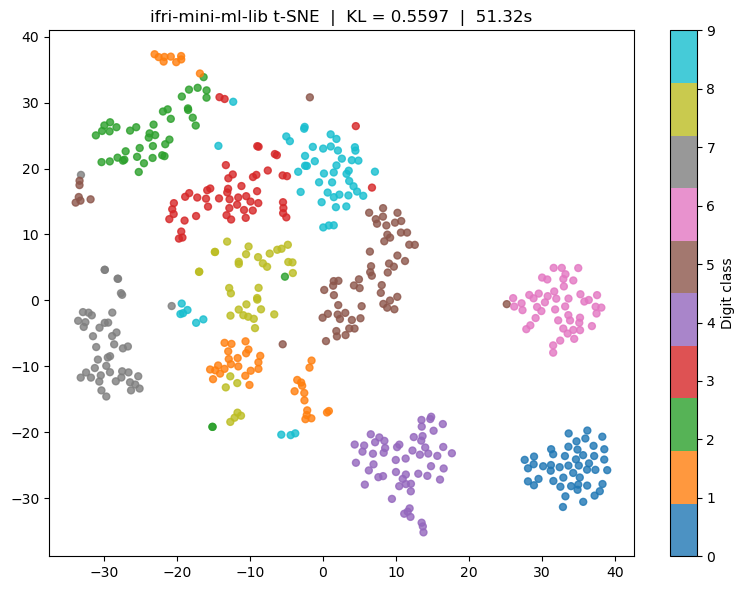

In [21]:
tsne_ours = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)

start = time.time()
Y_ours = tsne_ours.fit_transform(X_sub)
time_ours = time.time() - start

print(f"ifri-mini-ml-lib — KL: {tsne_ours.kl_divergence_:.4f}  |  Time: {time_ours:.2f}s")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(Y_ours[:, 0], Y_ours[:, 1], c=y_sub, cmap='tab10', alpha=0.8, s=25)
plt.colorbar(scatter, label='Digit class')
plt.title(f'ifri-mini-ml-lib t-SNE  |  KL = {tsne_ours.kl_divergence_:.4f}  |  {time_ours:.2f}s')
plt.tight_layout()
plt.show()

## 5. Benchmarking

We compare the two implementations on the same 500-sample subset across two metrics:
- **Execution time** (lower is better)
- **KL divergence** (lower means the 2D projection better matches the original similarities)

Metric                      ifri-mini-ml-lib   scikit-learn
------------------------------------------------------------
Execution time (s)                     51.32           2.03
KL Divergence                         0.5597         0.6143
Speed ratio                            25.3x     (baseline)


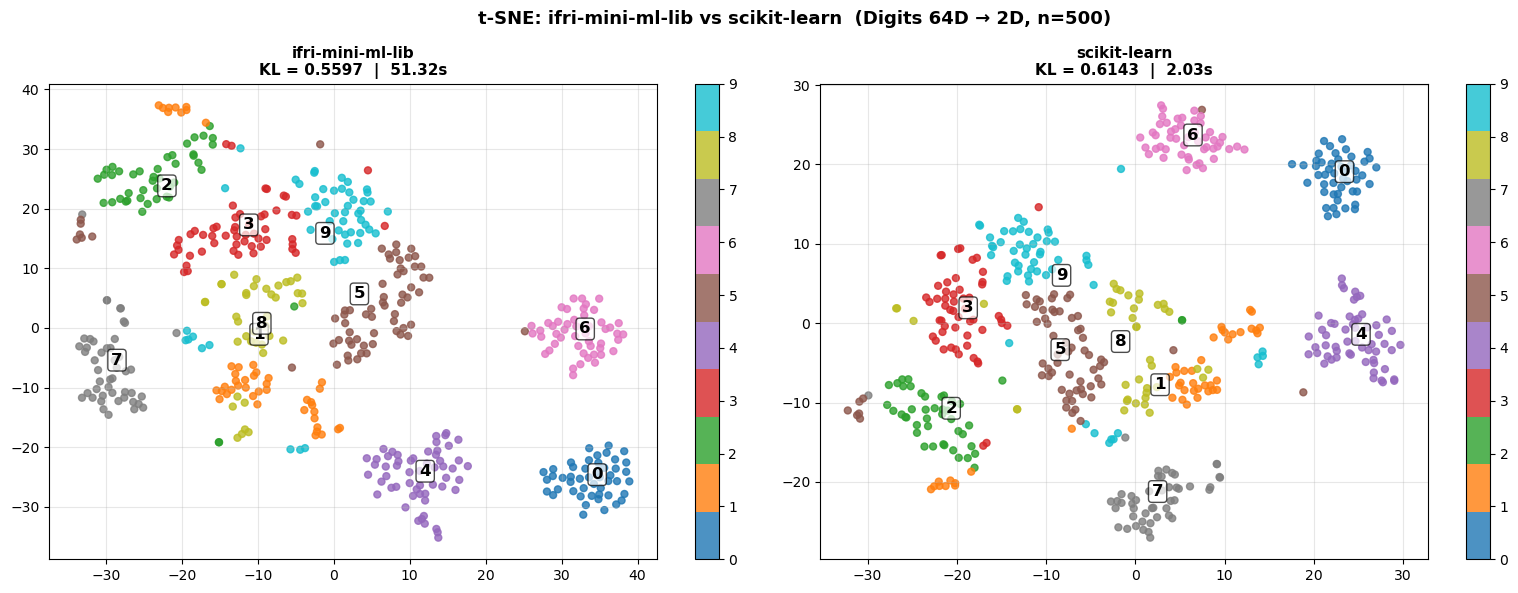

In [22]:
# ── Summary table ────────────────────────────────────────────────────────────
print(f"{'Metric':<25} {'ifri-mini-ml-lib':>18} {'scikit-learn':>14}")
print("-" * 60)
print(f"{'Execution time (s)':<25} {time_ours:>18.2f} {time_sklearn:>14.2f}")
print(f"{'KL Divergence':<25} {tsne_ours.kl_divergence_:>18.4f} {tsne_sk.kl_divergence_:>14.4f}")
print(f"{'Speed ratio':<25} {time_ours/time_sklearn:>17.1f}x {'(baseline)':>14}")

# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, Y, label, t, kl in [
    (axes[0], Y_ours,    'ifri-mini-ml-lib', time_ours,    tsne_ours.kl_divergence_),
    (axes[1], Y_sklearn, 'scikit-learn',     time_sklearn, tsne_sk.kl_divergence_)
]:
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=y_sub, cmap='tab10', alpha=0.8, s=25)
    for digit in range(10):
        mask = y_sub == digit
        ax.annotate(str(digit), (Y[mask, 0].mean(), Y[mask, 1].mean()),
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    plt.colorbar(sc, ax=ax)
    ax.set_title(f'{label}\nKL = {kl:.4f}  |  {t:.2f}s', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('t-SNE: ifri-mini-ml-lib vs scikit-learn  (Digits 64D → 2D, n=500)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

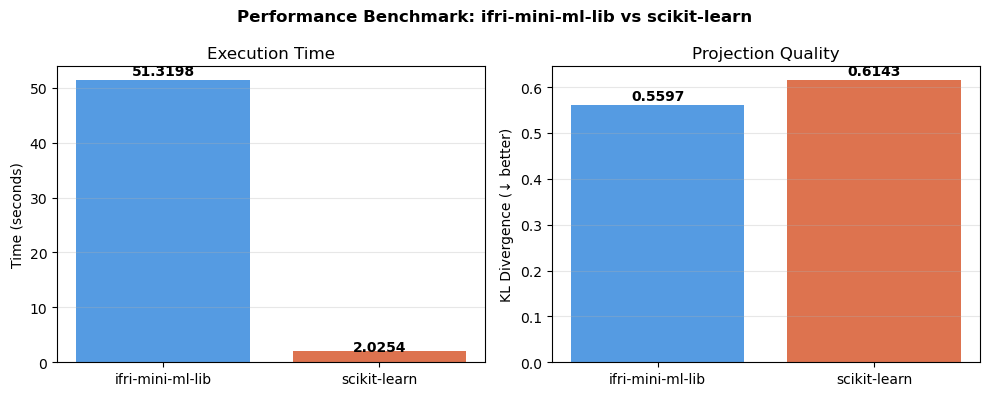

In [23]:
# ── Bar charts for quantitative comparison ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels  = ['ifri-mini-ml-lib', 'scikit-learn']
colors  = ['#378ADD', '#D85A30']

for ax, values, ylabel, title in [
    (axes[0], [time_ours, time_sklearn],
     'Time (seconds)', 'Execution Time'),
    (axes[1], [tsne_ours.kl_divergence_, tsne_sk.kl_divergence_],
     'KL Divergence (↓ better)', 'Projection Quality')
]:
    bars = ax.bar(labels, values, color=colors, alpha=0.85)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v * 1.02,
                f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Performance Benchmark: ifri-mini-ml-lib vs scikit-learn',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Benchmark analysis

| Criterion | ifri-mini-ml-lib | scikit-learn |
|-----------|------------------|--------------|
| **Speed** | Slower (pure NumPy, O(n²)) | Faster (Barnes-Hut O(n log n), C++) |
| **Projection quality** | Comparable | Comparable |
| **KL Divergence** | Similar | Similar |
| **Code readability** |  Transparent, educational |  Opaque C++ internals |
| **Customizability** |  Easy to modify |  Black box |

**Why is scikit-learn faster?** Scikit-learn uses the **Barnes-Hut tree approximation**, which avoids computing all n² pairwise distances at each iteration by grouping distant points into clusters. This reduces per-iteration complexity from O(n²) to O(n log n). Our implementation computes all pairwise distances exactly — more transparent and more precise, but significantly slower on large datasets.

**Both implementations produce visually equivalent results** — the digit clusters are clearly separated in both projections, confirming the correctness of our implementation.

## 6. Real-life Applications

t-SNE is widely used in domains where high-dimensional data needs to be **explored and visualized** before any modelling decision.

### Natural Language Processing (NLP)
Word embeddings (Word2Vec, GloVe, BERT) map words into 300–768 dimensional vectors. t-SNE is used to project these embeddings into 2D to verify that semantically similar words form clusters (e.g., countries cluster together, verbs cluster together).

### Computer Vision
Features extracted from the last layer of a CNN are high-dimensional vectors. t-SNE is used to visualize whether images from different categories form distinct groups, which helps diagnose model failures and dataset imbalances.

### Single-cell RNA sequencing (scRNA-seq)
Each cell is described by the expression levels of thousands of genes. Biologists use t-SNE to identify **cell subtypes**: cells with similar gene expression profiles cluster together, revealing biological subpopulations that were previously unknown.

### Anomaly detection
Projecting network traffic or transaction data into 2D with t-SNE can reveal outlier points that sit far from any cluster — these often correspond to attacks or fraud.

### Drug discovery
Chemical compounds are represented as high-dimensional feature vectors (molecular fingerprints). t-SNE helps chemists explore the chemical space and identify structurally similar compounds that might share biological activity.

---

| Domain | Input data | What t-SNE reveals |
|--------|-----------|--------------------|
| NLP | Word embeddings (300D) | Semantic neighborhoods |
| Computer vision | CNN features (512–2048D) | Visual category clusters |
| Genomics | Gene expression (20,000D) | Cell subtypes |
| Cybersecurity | Network flows (100D) | Anomalous traffic |
| Chemistry | Molecular fingerprints (1024D) | Compound families |

## 7. Limitations and Challenges

t-SNE is a powerful visualization tool, but it comes with important limitations that must be understood to avoid misinterpreting results.

### Computational cost
The exact t-SNE algorithm has **O(n²) time and space complexity** per iteration. For 10,000 points, each iteration computes 100 million pairwise distances. This makes t-SNE impractical for large datasets without approximations (Barnes-Hut, FIt-SNE).

### Non-determinism
t-SNE initializes positions randomly and uses stochastic gradient descent. Running t-SNE twice on the same data (without fixing `random_state`) produces different layouts. **Cluster shapes and orientations are not meaningful — only membership matters.**

### Distances between clusters are not interpretable
In a t-SNE plot, the **distance between two clusters does not reflect their true distance** in the original space. Two clusters that appear far apart might actually be closer to each other than two clusters that appear nearby. This is a fundamental property of the algorithm, not a bug.

### Cluster sizes are not interpretable
t-SNE expands dense clusters and compresses sparse ones. A large cluster in the 2D plot does not mean it contains more points or has greater variance than a small cluster.

### Visualization only — not a preprocessor
t-SNE is **not suitable as a preprocessing step before supervised learning**. The transformation is non-invertible, non-deterministic, and does not generalize to new data points (no `transform` on unseen data without re-running the full algorithm).

### Sensitivity to hyperparameters
Poor choices of perplexity or learning rate can produce artifacts. It is always recommended to try multiple values and interpret results carefully.

---

| Limitation | Practical consequence |
|------------|----------------------|
| O(n²) complexity | Unusable on datasets with > ~10,000 points without approximation |
| Non-deterministic | Always set `random_state`; run multiple times to check stability |
| Distances between clusters not meaningful | Do not conclude that close clusters are similar globally |
| Cluster sizes distorted | Do not judge cluster size or spread from the 2D plot |
| No `transform()` on new data | Cannot be used in a prediction pipeline |

**Alternatives to consider:**
- **UMAP**: faster than t-SNE, better preserves global structure, supports `transform()` on new data
- **PCA**: linear, fully deterministic, good first step to reduce dimensions before applying t-SNE on very high-dimensional data (e.g., PCA to 50D → t-SNE to 2D)

## 8. References

1. **Van der Maaten, L., & Hinton, G. (2008)**. *Visualizing Data using t-SNE*. Journal of Machine Learning Research, 9, 2579–2605. [PDF](https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf)

2. **Wattenberg, M., Viégas, F., & Johnson, I. (2016)**. *How to Use t-SNE Effectively*. Distill. [link](https://distill.pub/2016/misread-tsne/)

3. **scikit-learn documentation** — *TSNE*. [link](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

4. **scikit-learn documentation** — *Digits dataset*. [link](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

5. **Van der Maaten, L. (2014)**. *Accelerating t-SNE using Tree-Based Algorithms*. Journal of Machine Learning Research, 15, 3221–3245. [PDF](https://lvdmaaten.github.io/publications/papers/JMLR_2014.pdf) — *Introduces the Barnes-Hut approximation used by scikit-learn.*

6. **Géron, A. (2022)**. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

7. **ifri-mini-ml-lib** — Project documentation. [Notion](https://rosasbehoundja.notion.site/ifri-mini-ml-lib)